In [20]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy.stats import t as student_t
import optuna
from tqdm import tqdm
import plotly.graph_objects as go
from scipy.stats import norm
from itertools import combinations

In [78]:
p = pd.read_parquet('forecastLGBM/wheat_target_wheat_h5_fair.parquet')
p.head()

,y_true,y_pred,fold
Date,,,
2008-01-08,0.026639,0.004258,0
2008-01-09,0.040755,0.004258,0
2008-01-10,0.063653,0.004258,0
2008-01-11,0.056914,0.004258,0
2008-01-14,0.018369,0.004258,0


In [66]:
FORECAST_DIR = Path("forecastLGBM")
OUT_DIR = Path("pnl_tables")
OUT_DIR.mkdir(exist_ok=True)

COST = 2 / 10_000
ANN = 252

def parse_name(path):
    m = re.match(r"^(?P<asset>.+?)_target_(?P<target>.+?)_h(?P<h>\d+)_(?P<loss>.+)\.parquet$", path.name)
    if m is None:
        return None
    d = m.groupdict()
    d["h"] = int(d["h"])
    d["path"] = path
    return d

def scan_files(folder):
    folder = Path(folder)
    rows = [parse_name(p) for p in folder.rglob("*.parquet")]
    rows = [r for r in rows if r is not None]

    if len(rows) == 0:
        raise ValueError(f"No matching parquet files found in {folder}")

    return pd.DataFrame(rows).sort_values(["asset", "h", "loss"]).reset_index(drop=True)
    
def read_fcst(path):
    df = pd.read_parquet(path)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.set_index("Date")
    df.index = pd.to_datetime(df.index)
    return df[["y_true", "y_pred", "fold"]].sort_index().dropna()

def build_daily_returns(meta):
    out = {}
    for asset in meta["asset"].unique():
        paths = meta.query("asset == @asset and h == 1")["path"]
        if len(paths) == 0:
            continue
        rs = [read_fcst(p)["y_true"].rename(p.stem) for p in paths]
        out[asset] = pd.concat(rs, axis=1).mean(axis=1).dropna()
    return out

In [48]:
def signal_from_thresholds(pred, th_l, th_s):
    scale = max(abs(th_l), abs(th_s))

    if pd.isna(scale) or scale <= 0:
        return pd.Series(0.0, index=pred.index)

    s = pred / scale
    return s.clip(-1, 1).fillna(0.0)


def pnl_from_signal(signal, daily_log_ret, h, cost):
    idx = signal.index.intersection(daily_log_ret.index)

    signal = signal.reindex(idx).sort_index().fillna(0.0)
    r = daily_log_ret.reindex(idx).sort_index()

    pos = signal.rolling(h, min_periods=1).sum() / h

    ret = np.expm1(r)

    turnover = pos.diff().abs()
    turnover.iloc[0] = abs(pos.iloc[0])

    pnl = pos * ret - cost * turnover

    return pd.DataFrame({
        "signal": signal,
        "position": pos,
        "asset_ret": ret,
        "turnover": turnover,
        "pnl": pnl
    }).dropna()

In [5]:
def sharpe(x):
    x = pd.Series(x).dropna()
    if len(x) < 2 or x.std(ddof=1) == 0:
        return np.nan
    return np.sqrt(ANN) * x.mean() / x.std(ddof=1)

def sortino(x):
    x = pd.Series(x).dropna()
    d = x[x < 0]
    if len(d) < 2 or d.std(ddof=1) == 0:
        return np.nan
    return np.sqrt(ANN) * x.mean() / d.std(ddof=1)

def maxdd(x):
    eq = (1 + pd.Series(x).dropna()).cumprod()
    if eq.empty:
        return np.nan
    return (eq / eq.cummax() - 1).min()

def t_var_cvar(x, alpha=0.05):
    x = pd.Series(x).dropna()
    if len(x) < 30:
        return np.nan, np.nan
    df, loc, scale = student_t.fit(x)
    q = student_t.ppf(alpha, df)
    var = -(loc + scale * q)
    cvar = -loc + scale * (df + q ** 2) / (df - 1) * student_t.pdf(q, df) / alpha if df > 1 else np.nan
    return var, cvar
def metrics(pnl, pred):
    r = pnl["pnl"].dropna()
    total = (1 + r).prod() - 1
    ann_ret = (1 + total) ** (ANN / len(r)) - 1
    dd = maxdd(r)

    var_t, cvar_t = t_var_cvar(r)

    return {
        "IC_Spearman": pred["y_pred"].corr(pred["y_true"], method="spearman"),
        "IC_Pearson": pred["y_pred"].corr(pred["y_true"], method="pearson"),
        "Total_Return": total,
        "Ann_Return": ann_ret,
        "Ann_Vol": r.std(ddof=1) * np.sqrt(ANN),
        "Sharpe": sharpe(r),
        "Sortino": sortino(r),
        "MaxDD": dd,
        "Calmar": ann_ret / abs(dd) if pd.notna(dd) and dd != 0 else np.nan,
        "Hit_Rate": (r > 0).mean(),
        "VaR95_hist": -r.quantile(0.05),
        "CVaR95_hist": -r[r <= r.quantile(0.05)].mean(),
        "VaR95_t": var_t,
        "CVaR95_t": cvar_t,
        "AvgAbsPosition": pnl["position"].abs().mean(),
        "AvgTurnover": pnl["turnover"].mean(),
        "TotalTurnover": pnl["turnover"].sum(),
        "N": len(r)
    }

In [49]:
def opt_thresholds(calib, daily_ret, h, cost, n_grid=11, obj="sharpe"):
    pred = calib["y_pred"].dropna()

    if len(pred) < 15 or pred.nunique() < 5:
        return np.nan, np.nan

    th_s = pred.abs().quantile(0.75)
    th_l = pred.abs().quantile(0.75)

    if th_l <= 0:
        return np.nan, np.nan

    return th_l, th_s

In [7]:
def monthly_signals(df, daily_ret, h, cost, calib_days=21, n_grid=11, obj="sharpe"):
    sig = pd.Series(0.0, index=df.index)

    months = sorted(df.index.to_period("M").unique())

    for m in months:
        cur_idx = df.index[df.index.to_period("M") == m]
        start = cur_idx.min()

        hist = df[df.index < start]

        if len(hist) <= h:
            continue

        hist = hist.iloc[:-h]
        calib = hist.tail(calib_days)

        th_l, th_s = opt_thresholds(
            calib=calib,
            daily_ret=daily_ret,
            h=h,
            cost=cost,
            n_grid=n_grid,
            obj=obj
        )

        if pd.notna(th_l) and pd.notna(th_s):
            sig.loc[cur_idx] = signal_from_thresholds(
                df.loc[cur_idx, "y_pred"],
                th_l,
                th_s
            )

    return sig

In [8]:
def backtest_file(row, daily_returns, cost=COST, calib_days=21, n_grid=8, obj="sharpe"):
    df = read_fcst(row.path)

    sig = monthly_signals(
        df=df,
        daily_ret=daily_returns[row.asset],
        h=row.h,
        cost=cost,
        calib_days=calib_days,
        n_grid=n_grid,
        obj=obj
    )

    pnl = pnl_from_signal(sig, daily_returns[row.asset], row.h, cost)

    idx = pnl.index.intersection(df.index)
    pnl = pnl.loc[idx]
    pred = df.loc[idx]

    res = metrics(pnl, pred)
    res.update({
        "asset": row.asset,
        "h": row.h,
        "loss": row.loss,
        "file": row.path.name
    })

    return res, pnl
def run_all(folder=FORECAST_DIR, cost=COST, calib_days=21, n_grid=11, obj="sharpe"):
    meta = scan_files(folder)
    daily_returns = build_daily_returns(meta)

    rows = []
    pnl_store = {}

    for row in tqdm(list(meta.itertuples(index=False)), desc="Backtesting files"):
        if row.asset not in daily_returns:
            continue

        res, pnl = backtest_file(
            row=row,
            daily_returns=daily_returns,
            cost=cost,
            calib_days=calib_days,
            n_grid=n_grid,
            obj=obj
        )

        rows.append(res)
        pnl_store[(row.asset, row.h, row.loss)] = pnl

    summary = pd.DataFrame(rows)
    
    first = ["asset", "h", "loss", "IC_Spearman", "IC_Pearson", "Total_Return",
             "Ann_Return", "Ann_Vol", "Sharpe", "Sortino", "MaxDD", "Calmar",
             "Hit_Rate", "VaR95_hist", "CVaR95_hist", "VaR95_t", "CVaR95_t",
             "AvgAbsPosition", "AvgTurnover", "TotalTurnover", "N", "file"]

    summary = summary[[c for c in first if c in summary.columns]]
    summary = summary.sort_values(["asset", "h", "Sharpe"], ascending=[True, True, False])
    tables = {}

    for (asset, h), g in summary.groupby(["asset", "h"]):
        table = (
            g.drop(columns=["asset", "h", "file"], errors="ignore")
             .set_index("loss")
             .sort_values("Sharpe", ascending=False)
        )

        tables[(asset, h)] = table
        table.to_csv(OUT_DIR / f"{asset}_h{h}_metrics.csv")

    summary.to_csv(OUT_DIR / "all_metrics.csv", index=False)

    return summary, tables, pnl_store

In [67]:
summary, tables, pnl_store = run_all(
    folder=Path("forecastLGBM"),
    cost=2/ 10_000,
    calib_days=21,
    n_grid=8,
    obj="sharpe"
)

Backtesting files: 100%|██████████████████████| 168/168 [00:42<00:00,  3.93it/s]


In [68]:
for (asset, h), table in tables.items():
    print(f"\n===== {asset.upper()} | h={h} =====")
    display(table)


===== COPPER | h=1 =====


,IC_Spearman,IC_Pearson,Total_Return,Ann_Return,Ann_Vol,Sharpe,Sortino,MaxDD,Calmar,Hit_Rate,VaR95_hist,CVaR95_hist,VaR95_t,CVaR95_t,AvgAbsPosition,AvgTurnover,TotalTurnover,N
loss,,,,,,,,,,,,,,,,,,
huber,0.020507,0.011875,0.467527,0.022232,0.189771,0.210541,0.272374,-0.425935,0.052196,0.486806,0.017479,0.028709,0.016611,0.044809,0.601050,0.494830,2175.272589,4396
regression_l1,0.028588,0.019543,0.281948,0.014340,0.188964,0.169945,0.213826,-0.550449,0.026052,0.502957,0.017339,0.028983,0.016691,0.043718,0.605637,0.496132,2180.994100,4396
fair,0.014471,0.010481,0.150130,0.008051,0.189477,0.137090,0.174603,-0.561923,0.014327,0.487034,0.017343,0.028591,0.016860,0.046057,0.608244,0.448383,1971.093114,4396
mape,0.029293,0.019876,0.142198,0.007651,0.187678,0.134578,0.169115,-0.633103,0.012084,0.493176,0.017562,0.029171,0.016567,0.043431,0.604228,0.535899,2355.810233,4396
regression,0.015938,0.012023,-0.102115,-0.006156,0.193926,0.065189,0.081870,-0.583306,-0.010553,0.485441,0.017910,0.030414,0.017181,0.050425,0.613547,0.433716,1906.615217,4396
quantile,0.017119,0.013721,-0.253461,-0.016617,0.183773,0.000834,0.001059,-0.626380,-0.026528,0.487034,0.018028,0.028615,0.016700,0.042395,0.609366,0.526231,2313.312913,4396



===== COPPER | h=5 =====


,IC_Spearman,IC_Pearson,Total_Return,Ann_Return,Ann_Vol,Sharpe,Sortino,MaxDD,Calmar,Hit_Rate,VaR95_hist,CVaR95_hist,VaR95_t,CVaR95_t,AvgAbsPosition,AvgTurnover,TotalTurnover,N
loss,,,,,,,,,,,,,,,,,,
quantile,-0.015830,-0.012307,-0.278912,-0.018608,0.191469,-0.002206,-0.002793,-0.588498,-0.031619,0.484158,0.017466,0.029525,0.016973,0.038641,0.615480,0.076958,337.616926,4387
regression_l1,-0.009028,-0.030742,-0.463983,-0.035187,0.196184,-0.084294,-0.105584,-0.737990,-0.047679,0.468885,0.018266,0.030229,0.017444,0.043570,0.620219,0.069856,306.456421,4387
mape,-0.024462,-0.012560,-0.478271,-0.036683,0.160339,-0.152874,-0.193721,-0.670003,-0.054750,0.486437,0.015901,0.025029,0.014316,0.043901,0.505398,0.111055,487.199662,4387
fair,-0.036726,-0.023687,-0.706205,-0.067942,0.185727,-0.285665,-0.358443,-0.738775,-0.091965,0.475724,0.017483,0.028891,0.015879,0.033286,0.597140,0.080428,352.836150,4387
regression,-0.040619,-0.088303,-0.749014,-0.076335,0.186680,-0.331695,-0.390528,-0.814646,-0.093704,0.423752,0.017934,0.029345,0.017330,0.158668,0.549785,0.062017,272.069339,4387
huber,-0.054431,-0.053423,-0.851858,-0.103889,0.185324,-0.498672,-0.600082,-0.851858,-0.121956,0.471621,0.017806,0.029660,0.016238,0.041977,0.581351,0.084871,372.330914,4387



===== COPPER | h=10 =====


...

,IC_Spearman,IC_Pearson,Total_Return,Ann_Return,Ann_Vol,Sharpe,Sortino,MaxDD,Calmar,Hit_Rate,VaR95_hist,CVaR95_hist,VaR95_t,CVaR95_t,AvgAbsPosition,AvgTurnover,TotalTurnover,N
loss,,,,,,,,,,,,,,,,,,
quantile,-0.029785,-0.036509,-0.334647,-0.022494,0.281117,0.059094,0.093394,-0.687743,-0.032707,0.471527,0.026904,0.038205,2.803708e-02,4.181893e-02,0.815159,0.027195,122.729040,4513
mape,0.006083,0.001578,-0.213253,-0.013304,0.207748,0.040297,0.050668,-0.681141,-0.019531,0.480390,0.018997,0.031096,1.831999e-02,4.093128e-02,0.517752,0.108959,491.730594,4513
regression_l1,0.012061,0.026245,-0.541351,-0.042591,0.145396,-0.226496,-0.210395,-0.592217,-0.071918,0.258365,0.014566,0.025336,1.517701e-14,NaN,0.300766,0.031039,140.080090,4513
fair,-0.037431,-0.034830,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,0.000000,-0.000000,-0.000000,5.237218e-21,1.006101e-20,0.000000,0.000000,0.000000,4513
huber,-0.034536,-0.031757,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,0.000000,-0.000000,-0.000000,5.237218e-21,1.006101e-20,0.000000,0.000000,0.000000,4513
regression,-0.037431,-0.034830,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,0.000000,-0.000000,-0.000000,5.237218e-21,1.006101e-20,0.000000,0.000000,0.000000,4513



===== WHEAT | h=10 =====


,IC_Spearman,IC_Pearson,Total_Return,Ann_Return,Ann_Vol,Sharpe,Sortino,MaxDD,Calmar,Hit_Rate,VaR95_hist,CVaR95_hist,VaR95_t,CVaR95_t,AvgAbsPosition,AvgTurnover,TotalTurnover,N
loss,,,,,,,,,,,,,,,,,,
huber,-0.066577,-0.059134,0.042357,0.002323,0.010277,0.230897,0.029647,-0.029144,0.079698,0.006880,-0.000000,1.934599e-05,1.859188e-21,4.435215e-21,0.005311,0.000328,1.476636,4506
regression_l1,0.005368,-0.003388,-0.123006,-0.007314,0.210438,0.070289,0.094197,-0.713290,-0.010253,0.483799,0.021308,3.195810e-02,1.976070e-02,3.950832e-02,0.565313,0.049435,222.756347,4506
quantile,-0.023401,-0.039521,-0.320184,-0.021352,0.283282,0.064904,0.102236,-0.612243,-0.034875,0.472481,0.027002,3.858793e-02,2.818755e-02,4.174602e-02,0.826974,0.014686,66.175996,4506
mape,-0.010495,-0.014446,-0.374907,-0.025935,0.195284,-0.036995,-0.049002,-0.733498,-0.035357,0.483577,0.018917,2.940048e-02,1.770854e-02,4.055843e-02,0.495139,0.059818,269.541013,4506
regression,-0.065158,-0.052927,-0.000422,-0.000024,0.000085,-0.277586,-0.033591,-0.000448,-0.052677,0.002663,-0.000000,2.176254e-07,6.913133e-22,1.810945e-21,0.000036,0.000004,0.016050,4506
fair,-0.068094,-0.060832,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,0.000000,-0.000000,-0.000000e+00,5.237218e-21,1.006101e-20,0.000000,0.000000,0.000000,4506



===== WHEAT | h=20 =====


,IC_Spearman,IC_Pearson,Total_Return,Ann_Return,Ann_Vol,Sharpe,Sortino,MaxDD,Calmar,Hit_Rate,VaR95_hist,CVaR95_hist,VaR95_t,CVaR95_t,AvgAbsPosition,AvgTurnover,TotalTurnover,N
loss,,,,,,,,,,,,,,,,,,
quantile,-0.055262,-0.052072,-0.194901,-0.012078,0.278213,0.094729,0.153908,-0.571440,-0.021135,0.471530,0.026365,0.036864,2.782584e-02,3.991593e-02,0.840667,0.008340,37.494398,4496
regression_l1,0.003073,-0.022432,-0.092183,-0.005406,0.201367,0.073827,0.096441,-0.656875,-0.008230,0.484431,0.019962,0.030883,1.878869e-02,3.808301e-02,0.545719,0.028298,127.228573,4496
mape,0.016102,0.028886,-0.229154,-0.014482,0.192268,0.020333,0.026075,-0.569389,-0.025434,0.465970,0.019865,0.029922,1.779888e-02,3.894907e-02,0.513025,0.027943,125.631233,4496
huber,-0.034717,-0.011012,-0.357741,-0.024511,0.107642,-0.176867,-0.126594,-0.493575,-0.049661,0.138123,0.008155,0.017923,3.281192e-20,6.784570e-20,0.147251,0.008859,39.828696,4496
regression,-0.034294,-0.009572,-0.301105,-0.019880,0.087427,-0.186271,-0.107769,-0.399778,-0.049727,0.084075,0.004110,0.013100,2.895260e-21,6.579832e-21,0.079935,0.005645,25.378987,4496
fair,-0.071748,-0.082112,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,0.000000,-0.000000,-0.000000,5.237218e-21,1.006101e-20,0.000000,0.000000,0.000000,4496


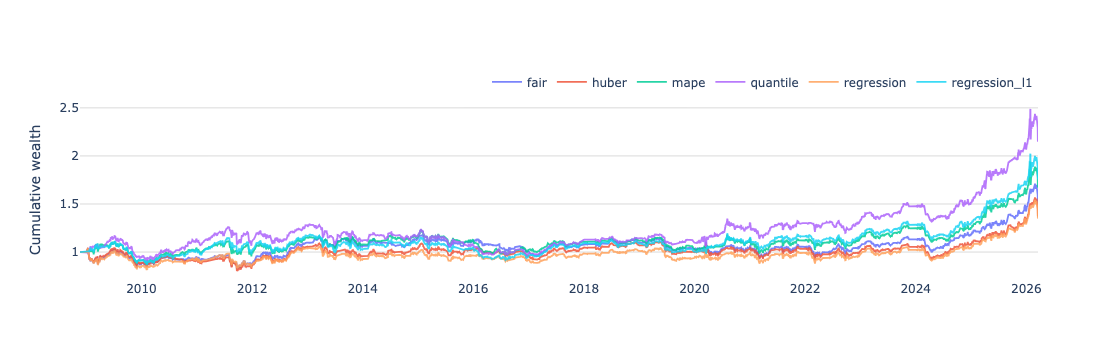

In [70]:
asset = "gold"
h = 10

dfs = []

for (a, hh, loss), pnl in pnl_store.items():
    if a == asset and hh == h:
        dfs.append(pnl["pnl"].rename(loss))

df = pd.concat(dfs, axis=1).sort_index()
cum = (1 + df).cumprod()

fig = go.Figure()

for col in cum.columns:
    fig.add_trace(go.Scatter(
        x=cum.index,
        y=cum[col],
        mode="lines",
        name=col,
        line=dict(width=1.8),
        opacity=0.85
    ))

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    xaxis=dict(
        title=None,
        showgrid=False
    ),
    yaxis=dict(
        title="Cumulative wealth",
        showgrid=True,
        gridcolor="rgba(0,0,0,0.15)"
    )
)

fig.show()

Diebold-Mariana test

In [71]:
def dm_test(e1, e2, h=1, power=2):
    e1 = pd.Series(e1).dropna()
    e2 = pd.Series(e2).dropna()

    idx = e1.index.intersection(e2.index)
    e1 = e1.loc[idx]
    e2 = e2.loc[idx]

    d = e1.abs() ** power - e2.abs() ** power
    d = d.dropna()

    n = len(d)
    if n < 20:
        return np.nan, np.nan, np.nan

    max_lag = max(h - 1, 0)

    gamma0 = np.var(d, ddof=1)
    var_d = gamma0

    for lag in range(1, max_lag + 1):
        gamma = np.cov(d.iloc[lag:], d.iloc[:-lag], ddof=1)[0, 1]
        var_d += 2 * (1 - lag / (max_lag + 1)) * gamma

    dm_stat = d.mean() / np.sqrt(var_d / n)
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))

    return dm_stat, p_value, d.mean()

In [72]:
def run_dm_tests(folder=FORECAST_DIR, power=2):
    meta = scan_files(folder)
    rows = []

    for (asset, h), g in meta.groupby(["asset", "h"]):
        data = {}

        for row in g.itertuples(index=False):
            df = read_fcst(row.path)
            err = df["y_true"] - df["y_pred"]
            data[row.loss] = err

        for loss_1, loss_2 in combinations(data.keys(), 2):
            dm_stat, p_value, mean_diff = dm_test(
                data[loss_1],
                data[loss_2],
                h=h,
                power=power
            )

            rows.append({
                "asset": asset,
                "h": h,
                "loss_1": loss_1,
                "loss_2": loss_2,
                "DM_stat": dm_stat,
                "p_value": p_value,
                "mean_loss_diff": mean_diff,
                "better_loss": loss_1 if mean_diff < 0 else loss_2
            })

    return pd.DataFrame(rows)

In [73]:
dm_results = run_dm_tests(
    folder=FORECAST_DIR,
    power=2
)

dm_results.head()

/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_87329/2062561808.py:25: RuntimeWarning:

invalid value encountered in scalar divide

/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_87329/2062561808.py:25: RuntimeWarning:

invalid value encountered in scalar divide

/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_87329/2062561808.py:25: RuntimeWarning:

invalid value encountered in scalar divide

/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_87329/2062561808.py:25: RuntimeWarning:

invalid value encountered in scalar divide

/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_87329/2062561808.py:25: RuntimeWarning:

invalid value encountered in scalar divide



,asset,h,loss_1,loss_2,DM_stat,p_value,mean_loss_diff,better_loss
0,copper,1,fair,huber,-2.499753,1.242798e-02,-1.596762e-06,fair
1,copper,1,fair,mape,-7.103728,1.214362e-12,-1.544077e-05,fair
2,copper,1,fair,quantile,-2.354447,1.855031e-02,-2.811591e-06,fair
3,copper,1,fair,regression,2.110228,3.483875e-02,9.386065e-07,regression
4,copper,1,fair,regression_l1,-1.431148,1.523879e-01,-1.678099e-06,fair


In [74]:
dm_results.query("p_value < 0.05").sort_values(["asset", "h", "p_value"])

,asset,h,loss_1,loss_2,DM_stat,p_value,mean_loss_diff,better_loss
11,copper,1,mape,regression_l1,7.508542,5.973000e-14,0.000014,regression_l1
10,copper,1,mape,regression,7.186037,6.670220e-13,0.000016,regression
1,copper,1,fair,mape,-7.103728,1.214362e-12,-0.000015,fair
9,copper,1,mape,quantile,6.649345,2.944001e-11,0.000013,quantile
5,copper,1,huber,mape,-6.619416,3.606204e-11,-0.000014,huber
...,...,...,...,...,...,...,...,...
407,wheat,20,fair,quantile,-9.853145,0.000000e+00,-0.011485,fair
411,wheat,20,huber,quantile,-9.980587,0.000000e+00,-0.011508,huber
414,wheat,20,mape,quantile,-9.792247,0.000000e+00,-0.011462,mape
417,wheat,20,quantile,regression,9.978971,0.000000e+00,0.011513,regression


In [75]:
pnl["correct_direction"] = np.sign(pnl["position"]) == np.sign(pnl["asset_ret"])
pnl.loc[pnl["position"] != 0, "correct_direction"].mean()

np.float64(0.4973786186459995)

In [76]:
pnl = pnl_store[("gold", 10, "huber")]
pnl[["signal", "position", "turnover", "pnl"]].describe()

,signal,position,turnover,pnl
count,4291.000000,4291.000000,4291.000000,4291.000000
mean,0.118053,0.117005,0.047329,0.000098
std,0.719957,0.635356,0.046996,0.006986
min,-1.000000,-1.000000,0.000000,-0.078317
25%,-0.498480,-0.423168,0.007953,-0.002227
50%,0.177350,0.158813,0.034010,0.000030
75%,0.873765,0.695661,0.072203,0.002463
max,1.000000,1.000000,0.200000,0.056073
